# Chapter 17: N-Linearities and Multiple View Tensors

Source orientation: printed pages 411-433; PDF pages 429-451.

This notebook turns the chapter into an executable projective-vision lab. The source pages are used for orientation only: the prose, code, diagrams, and artifacts below are original and do not reproduce textbook passages, figures, screenshots, page crops, or exercise text.


## Chapter Goal

The chapter's central move is to derive two-, three-, and four-view constraints from the same determinant idea: image measurements back-project to rays or planes in 3-space, and consistency appears when selected row determinants vanish. By the end of this notebook, you should be able to:

- compute the fundamental matrix, trifocal tensor, and quadrifocal tensor from camera rows;
- read point and line correspondences as multilinear equations;
- explain why a four-view point match gives 16 independent equations, not 81;
- use counting arguments to separate algebraic array size from geometric degrees of freedom;
- choose numerically stable equations by replacing a point with orthonormal lines through it.


## Computational Translation Guide

| Book idea | Computational object in this notebook | What we check |
| --- | --- | --- |
| A point measurement back-projects to a ray; an image line back-projects to a plane | Homogeneous vectors and `line @ P` plane rows | incidence residuals `line @ (P @ X)` and plane determinants |
| Bilinear relation | A `3 x 3` matrix assembled from `4 x 4` row determinants | `x2.T @ F @ x1 == 0` and `rank(F) == 2` |
| Trilinear relation | A `3 x 3 x 3` tensor from determinants with two rows of one camera and one from each other camera | point-line-line and point-point-point residuals vanish |
| Quadrilinear relation | A `3 x 3 x 3 x 3` tensor from one row of each of four cameras | four-line and three-line contractions vanish |
| Independent equations | Kronecker products of skew matrices built from image points | rank curve and equal nonzero singular values |
| Plane plus parallax | camera blocks known up to last columns after plane homographies are fixed | reduced degrees of freedom and correspondence counts |

All equalities involving homogeneous quantities are interpreted up to scale. The code therefore normalizes for display but uses incidence, rank, determinant, and singular-value tests for validation.


## Library Routing

| Chapter concept | Representation | Library choice | Why this route |
| --- | --- | --- | --- |
| Camera-row determinant definitions of `F`, `T`, and `Q` | explicit row selection, determinants, tensor contractions | `numpy` | keeps the multilinear algebra visible and avoids hiding the chapter's main construction inside a vision API |
| Equal singular values of point equations | symbolic skew-matrix identity plus numeric SVD | `sympy`, `numpy` | the symbolic identity explains the proof move; SVD shows the actual rank profile used by solvers |
| Back-projected planes meeting in 3-space | interactive 3D planes, cameras, and common point | `plotly` | the learner can rotate the construction and inspect why a determinant vanishes |
| Tensor sparsity and correspondence counting | heatmaps and compact tables | `matplotlib`, `pandas` | durable static artifacts are best for audit-friendly counts and zero patterns |
| Dependency structure across tensors and equations | directed concept graph | `networkx`, `matplotlib` | the chapter is a ladder of constructions; graph edges make the dependencies explicit |
| Artifact display and validation | book-local PNG/HTML/CSV/JSON | course `utils.artifacts` | keeps paths relative to the book and makes final checks enforce artifact integrity |


## Chapter-Specific Storyboard

| Step | Visual artifact | Learner inspection target | Validation |
| --- | --- | --- | --- |
| 1 | `figures/determinant-row-selection-ladder.png` | how `F`, `T`, and `Q` differ only by which camera rows enter a `4 x 4` determinant | graph node/edge counts and tensor shape checks |
| 2 | `interactive/backprojected-plane-intersection.html` | four image lines back-project to four planes whose determinant vanishes when they share a 3D point | four-plane determinant and line incidence residuals |
| 3 | `figures/quadrifocal-tensor-slices-and-affine-zero-pattern.png` | the quadrifocal tensor is a `3^4` array; affine cameras force a visible zero pattern | affine nonzero count equals 48 |
| 4 | `figures/quadrifocal-point-rank-profile.png` | a single point match supplies 16 equal-strength equations; multiple matches have pairwise dependencies | rank formula through five points; six camera-consistent tracks leave one homogeneous tensor null direction |
| 5 | `figures/correspondence-counting-dashboard.png` | projective, affine, and plane-plus-parallax counts are different because the remaining camera freedom is different | table values match the formulas used in the chapter |
| 6 | `checks/tensor-constraint-invariants.json` and `tables/correspondence-counts.csv` | numeric residuals, ranks, counts, and artifact inventory | final sanity cell asserts residual tolerances and nonzero artifact sizes |


In [1]:
from pathlib import Path
import sys

start = Path.cwd().resolve()
book_name = "Multiple-View-Geometry-in-Computer-Vision"
candidates = [start, start / book_name, *start.parents]
BOOK_ROOT = None
for candidate in candidates:
    if (candidate / "00-book-index.ipynb").exists() and (candidate / "utils").exists():
        BOOK_ROOT = candidate
        break
if BOOK_ROOT is None:
    raise RuntimeError("Could not find the MVG book root. Run from the book tree or workspace root.")

if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

TOPIC = "chapter-17"
ARTIFACT_ROOT = BOOK_ROOT / "artifacts" / TOPIC
ARTIFACT_ROOT.mkdir(parents=True, exist_ok=True)
BOOK_ROOT.name


'Multiple-View-Geometry-in-Computer-Vision'

In [2]:
import itertools
import json
import math

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import sympy as sp

from utils.artifacts import (
    assert_artifacts,
    display_artifact,
    relative_to_book,
    save_csv,
    save_json,
    save_matplotlib,
    save_plotly_html,
)

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 10,
})

rng = np.random.default_rng(17017)
figure_paths = []
data_paths = []
validation = {}


## Determinants as a Tensor Ladder

A camera row is a plane coefficient in homogeneous 3-space. Chapter 17 uses that fact repeatedly. For two views, omitting one row from each camera leaves four rows and gives an entry of the fundamental matrix. For three views, two rows from one camera plus one row from each of the other two views give a trifocal entry. For four views, one row from each camera gives a quadrifocal entry.

The graph below is a dependency map, not a decorative overview. Follow an edge to see which construction reuses the previous one: back-projected planes feed row determinants; row determinants feed tensors; tensors feed correspondence equations; equation rank and counting decide how many measurements are useful.


In [3]:
def levi_civita_3() -> np.ndarray:
    eps = np.zeros((3, 3, 3), dtype=float)
    for perm in itertools.permutations(range(3)):
        inversions = sum(perm[i] > perm[j] for i in range(3) for j in range(i + 1, 3))
        eps[perm] = -1.0 if inversions % 2 else 1.0
    return eps

EPS = levi_civita_3()


def normalize_h(x: np.ndarray) -> np.ndarray:
    x = np.asarray(x, dtype=float)
    if abs(x[-1]) > 1e-12:
        return x / x[-1]
    n = np.linalg.norm(x)
    return x / n if n else x


def camera_center(P: np.ndarray) -> np.ndarray:
    _, _, vt = np.linalg.svd(P)
    C = vt[-1]
    return C[:3] / C[3]


def project_h(P: np.ndarray, X: np.ndarray) -> np.ndarray:
    return normalize_h(P @ X)


def line_through_h(a: np.ndarray, b: np.ndarray) -> np.ndarray:
    line = np.cross(normalize_h(a), normalize_h(b))
    n = np.linalg.norm(line[:2])
    return line / n if n > 1e-12 else line


def image_line_through_point(x: np.ndarray, angle: float) -> np.ndarray:
    x = normalize_h(x)
    direction = np.array([math.cos(angle), math.sin(angle), 0.0])
    y = x + 0.35 * direction
    y[2] = x[2]
    return line_through_h(x, y)


def backproject_plane(P: np.ndarray, line: np.ndarray) -> np.ndarray:
    plane = line @ P
    n = np.linalg.norm(plane[:3])
    return plane / n if n > 1e-12 else plane


def make_projective_cameras() -> list[np.ndarray]:
    A = np.array([[1.0, 0.0, 0.0, 0.0], [0.0, 1.0, 0.0, 0.0], [0.0, 0.0, 1.0, 0.0]])
    B = np.array([[1.08, 0.06, 0.12, 0.85], [-0.04, 1.02, -0.10, 0.18], [0.015, 0.030, 1.00, 0.55]])
    C = np.array([[0.92, -0.10, 0.16, -0.70], [0.08, 1.04, 0.07, 0.42], [-0.020, 0.025, 1.00, 0.48]])
    D = np.array([[1.03, 0.14, -0.05, 0.28], [-0.09, 0.95, 0.12, -0.63], [0.025, -0.018, 1.00, 0.62]])
    return [A, B, C, D]


def sample_world_points(n: int) -> np.ndarray:
    base = rng.normal(size=(n, 3))
    base[:, 2] = 3.6 + 0.45 * np.arange(n) + 0.15 * base[:, 2]
    base[:, 0] *= 0.55
    base[:, 1] *= 0.45
    return np.column_stack([base, np.ones(n)])

cameras = make_projective_cameras()
A, B, C, D = cameras
world_points = sample_world_points(8)
tracks = [[project_h(P, X) for P in cameras] for X in world_points]

validation["camera_ranks"] = [int(np.linalg.matrix_rank(P)) for P in cameras]
assert validation["camera_ranks"] == [3, 3, 3, 3]


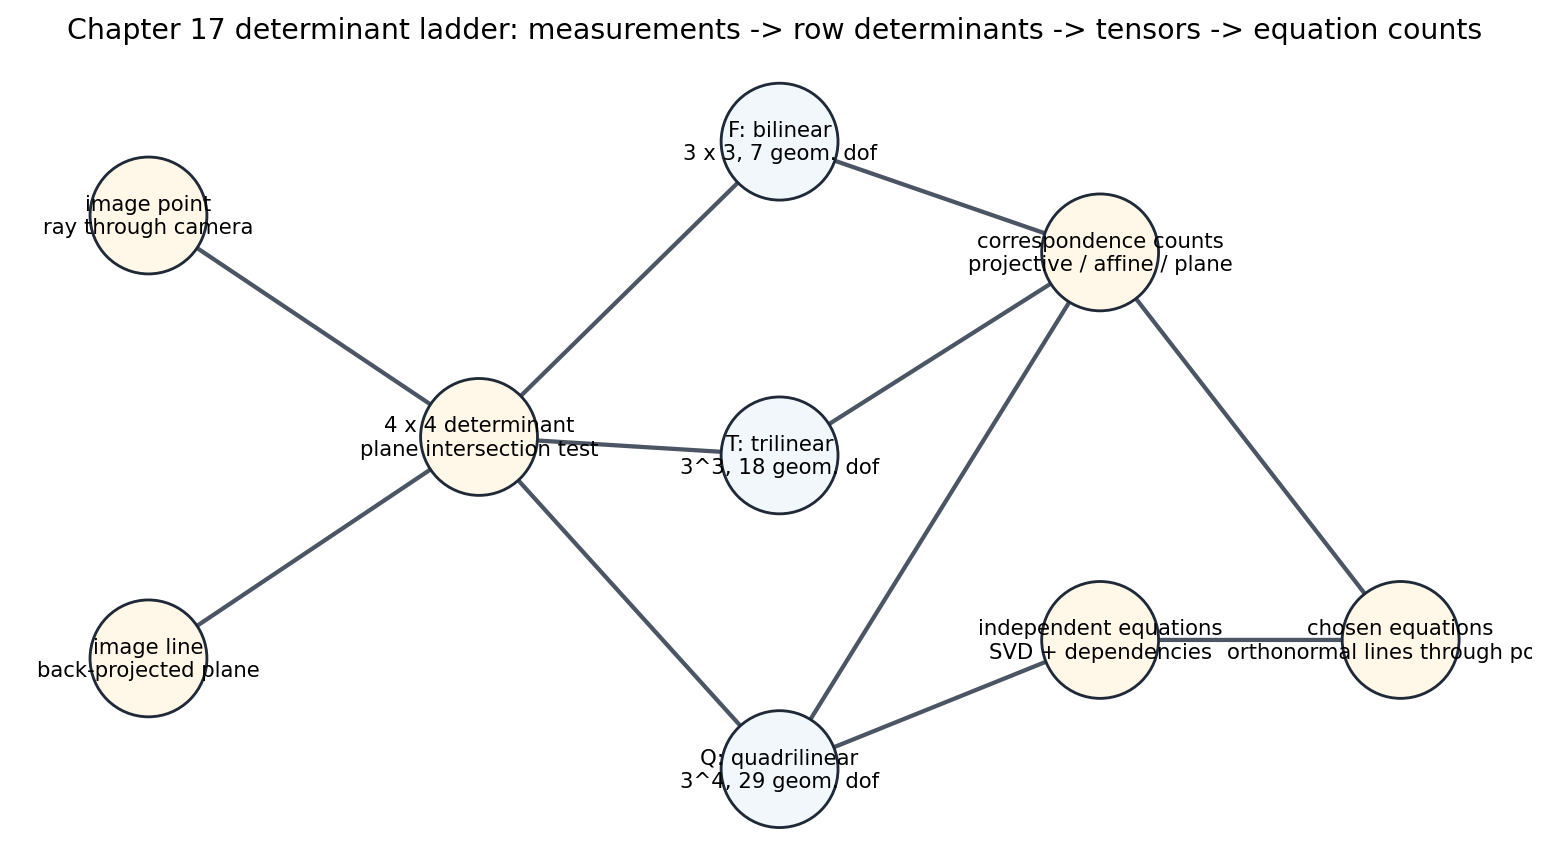

In [4]:
def make_ladder_graph() -> nx.DiGraph:
    G = nx.DiGraph()
    nodes = {
        "image point": "image point/nray through camera",
        "image line": "image line/nback-projected plane",
        "4x4 determinant": "4 x 4 determinant/nplane intersection test",
        "F": "F: bilinear/n3 x 3, 7 geom. dof",
        "T": "T: trilinear/n3^3, 18 geom. dof",
        "Q": "Q: quadrilinear/n3^4, 29 geom. dof",
        "rank": "independent equations/nSVD + dependencies",
        "counts": "correspondence counts/nprojective / affine / plane",
        "stable lines": "chosen equations/northonormal lines through points",
    }
    for key, label in nodes.items():
        G.add_node(key, label=label)
    G.add_edges_from([
        ("image point", "4x4 determinant"), ("image line", "4x4 determinant"),
        ("4x4 determinant", "F"), ("4x4 determinant", "T"), ("4x4 determinant", "Q"),
        ("F", "counts"), ("T", "counts"), ("Q", "counts"), ("Q", "rank"),
        ("rank", "stable lines"), ("stable lines", "counts"),
    ])
    return G

G = make_ladder_graph()
pos = {
    "image point": (-2.7, 1.0), "image line": (-2.7, -0.2), "4x4 determinant": (-1.05, 0.4),
    "F": (0.45, 1.2), "T": (0.45, 0.35), "Q": (0.45, -0.5),
    "rank": (2.05, -0.15), "counts": (2.05, 0.9), "stable lines": (3.55, -0.15),
}
fig, ax = plt.subplots(figsize=(11.5, 5.8))
node_colors = ["#f2f7fb" if n in {"F", "T", "Q"} else "#fff7e8" for n in G.nodes]
nx.draw_networkx_edges(G, pos, ax=ax, arrows=True, arrowstyle="-|>", arrowsize=16, width=1.8, edge_color="#4b5563")
nx.draw_networkx_nodes(G, pos, ax=ax, node_size=2450, node_color=node_colors, edgecolors="#1f2937", linewidths=1.2)
nx.draw_networkx_labels(G, pos, labels=nx.get_node_attributes(G, "label"), ax=ax, font_size=9)
ax.set_title("Chapter 17 determinant ladder: measurements -> row determinants -> tensors -> equation counts", pad=16)
ax.set_axis_off()
ladder_path = save_matplotlib(fig, TOPIC, "figures", "determinant-row-selection-ladder.png", dpi=170)
plt.close(fig)
figure_paths.append(ladder_path)
validation["ladder_graph"] = {"nodes": G.number_of_nodes(), "edges": G.number_of_edges()}
display_artifact(ladder_path, width=940)


## Row-Determinant Tensors

The next cell implements the tensor definitions directly from camera rows. This is intentionally low-level: the code exposes which rows enter each determinant and which indices remain free.

For a valid synthetic track, every point or line relation below should be numerically close to zero. A failed residual usually means one of three things: the correspondence is not geometrically consistent, a line was not chosen through the measured point, or an index convention was transposed.


In [5]:
def fundamental_from_row_determinants(P: np.ndarray, Q: np.ndarray) -> np.ndarray:
    F = np.zeros((3, 3), dtype=float)
    for i in range(3):
        rows_p = np.delete(P, i, axis=0)
        for j in range(3):
            rows_q = np.delete(Q, j, axis=0)
            F[j, i] = ((-1) ** (i + j)) * np.linalg.det(np.vstack([rows_p, rows_q]))
    return F / np.linalg.norm(F)


def trifocal_from_rows(P: np.ndarray, Q: np.ndarray, R: np.ndarray) -> np.ndarray:
    T = np.zeros((3, 3, 3), dtype=float)
    for i, q, r in itertools.product(range(3), repeat=3):
        total = 0.0
        for l, m in itertools.product(range(3), repeat=2):
            total += 0.5 * EPS[i, l, m] * np.linalg.det(np.vstack([P[l], P[m], Q[q], R[r]]))
        T[i, q, r] = total
    return T / np.linalg.norm(T)


def quadrifocal_from_rows(P: np.ndarray, Q: np.ndarray, R: np.ndarray, S: np.ndarray) -> np.ndarray:
    Quad = np.zeros((3, 3, 3, 3), dtype=float)
    for p, q, r, s in itertools.product(range(3), repeat=4):
        Quad[p, q, r, s] = np.linalg.det(np.vstack([P[p], Q[q], R[r], S[s]]))
    return Quad / np.linalg.norm(Quad)


def contract4(Q: np.ndarray, a: np.ndarray, b: np.ndarray, c: np.ndarray, d: np.ndarray) -> float:
    return float(np.einsum("p,q,r,s,pqrs->", a, b, c, d, Q))


def contract3_lines_to_view1(Q: np.ndarray, b: np.ndarray, c: np.ndarray, d: np.ndarray) -> np.ndarray:
    return np.einsum("q,r,s,pqrs->p", b, c, d, Q)


def point_trifocal_residuals(T: np.ndarray, x1: np.ndarray, x2: np.ndarray, x3: np.ndarray) -> np.ndarray:
    return np.einsum("i,j,k,jqu,krv,iqr->uv", x1, x2, x3, EPS, EPS, T)


def point_line_line_residual(T: np.ndarray, x1: np.ndarray, l2: np.ndarray, l3: np.ndarray) -> float:
    return float(np.einsum("i,q,r,iqr->", x1, l2, l3, T))

F12 = fundamental_from_row_determinants(A, B)
T123 = trifocal_from_rows(A, B, C)
Q1234 = quadrifocal_from_rows(A, B, C, D)

X0, X1 = world_points[0], world_points[1]
x1, x2, x3, x4 = tracks[0]
line_angles = [0.25, 1.15, -0.65, 0.72]
point_lines = [image_line_through_point(x, angle) for x, angle in zip([x1, x2, x3, x4], line_angles)]
planes = [backproject_plane(P, l) for P, l in zip(cameras, point_lines)]
line_from_world_in_views = [line_through_h(project_h(P, X0), project_h(P, X1)) for P in cameras]

validation.update({
    "tensor_shapes": {"F": list(F12.shape), "T": list(T123.shape), "Q": list(Q1234.shape)},
    "fundamental_rank": int(np.linalg.matrix_rank(F12, tol=1e-10)),
    "fundamental_det_abs": float(abs(np.linalg.det(F12))),
    "fundamental_epipolar_abs": float(abs(x2 @ F12 @ x1)),
    "trifocal_point_point_point_max_abs": float(np.max(np.abs(point_trifocal_residuals(T123, x1, x2, x3)))),
    "trifocal_point_line_line_abs": float(abs(point_line_line_residual(T123, x1, point_lines[1], point_lines[2]))),
    "quadrifocal_four_line_abs": float(abs(contract4(Q1234, *point_lines))),
    "quadrifocal_three_corresponding_lines_norm": float(np.linalg.norm(contract3_lines_to_view1(Q1234, line_from_world_in_views[1], line_from_world_in_views[2], line_from_world_in_views[3]))),
    "backprojected_plane_det_abs": float(abs(np.linalg.det(np.vstack(planes)))),
    "max_line_incidence_abs": float(max(abs(l @ x) for l, x in zip(point_lines, [x1, x2, x3, x4]))),
    "max_plane_point_incidence_abs": float(max(abs(pi @ X0) for pi in planes)),
})
validation["tensor_shapes"]


{'F': [3, 3], 'T': [3, 3, 3], 'Q': [3, 3, 3, 3]}

## Four Back-Projected Planes

A quadrifocal line equation is easiest to see in 3D. Choose one image line in each view so that every line contains the projection of the same world point. Each line back-projects to a plane through the corresponding camera center and the world point. The determinant of those four planes is zero because the planes share the point.

Rotate the HTML artifact and inspect the common intersection: the colored planes are different, but each is anchored by its camera center and the same black world point.


In [6]:
def plane_patch(plane: np.ndarray, center: np.ndarray, anchor: np.ndarray, radius: float = 1.15, samples: int = 2):
    n = plane[:3]
    n = n / np.linalg.norm(n)
    u = center - anchor
    u = u - np.dot(u, n) * n
    if np.linalg.norm(u) < 1e-9:
        u = np.cross(n, np.array([1.0, 0.0, 0.0]))
    u = u / np.linalg.norm(u)
    v = np.cross(n, u)
    grid = np.linspace(-radius, radius, samples)
    xx, yy = np.meshgrid(grid, grid)
    pts = anchor + xx[..., None] * u + yy[..., None] * v
    return pts[..., 0], pts[..., 1], pts[..., 2]

centers = [camera_center(P) for P in cameras]
anchor = X0[:3] / X0[3]
colors = ["rgba(37, 99, 235, 0.30)", "rgba(220, 38, 38, 0.28)", "rgba(5, 150, 105, 0.28)", "rgba(147, 51, 234, 0.27)"]
line_colors = ["#2563eb", "#dc2626", "#059669", "#9333ea"]
fig = go.Figure()
for idx, (plane, center, color, line_color) in enumerate(zip(planes, centers, colors, line_colors), start=1):
    Xp, Yp, Zp = plane_patch(plane, center, anchor)
    fig.add_trace(go.Surface(x=Xp, y=Yp, z=Zp, showscale=False, opacity=0.42, colorscale=[[0, color], [1, color]], name=f"plane from view {idx}"))
    fig.add_trace(go.Scatter3d(x=[center[0], anchor[0]], y=[center[1], anchor[1]], z=[center[2], anchor[2]], mode="lines", line=dict(color=line_color, width=5), name=f"ray through chosen line {idx}"))
fig.add_trace(go.Scatter3d(x=[c[0] for c in centers], y=[c[1] for c in centers], z=[c[2] for c in centers], mode="markers+text", marker=dict(size=6, color=line_colors), text=["C1", "C2", "C3", "C4"], textposition="top center", name="camera centers"))
fig.add_trace(go.Scatter3d(x=[anchor[0]], y=[anchor[1]], z=[anchor[2]], mode="markers+text", marker=dict(size=7, color="black"), text=["X"], textposition="bottom center", name="common world point"))
fig.update_layout(title="Four image lines back-project to four planes meeting at one 3D point", scene=dict(xaxis_title="X", yaxis_title="Y", zaxis_title="Z", aspectmode="data"), margin=dict(l=0, r=0, t=45, b=0), legend=dict(orientation="h", yanchor="bottom", y=0.0, xanchor="left", x=0.0))
plane_html_path = save_plotly_html(fig, TOPIC, "interactive", "backprojected-plane-intersection.html")
figure_paths.append(plane_html_path)
display_artifact(plane_html_path, width=940, height=620)


.venv/Lib/site-packages/IPython/core/display.py:447: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


## Quadrifocal Tensor Slices and the Affine Zero Pattern

The quadrifocal tensor has 81 entries, but not all entries behave the same way. Flattening the first two indices against the last two gives a `9 x 9` view of its scale pattern. Repeating the construction with affine cameras reveals a structural sparsity: if two or more selected camera rows are the shared affine last row, the determinant has repeated rows and vanishes.

The affine count is not a numerical accident. There are `2^4 = 16` entries with no affine last row and `4 * 2^3 = 32` entries with exactly one such row, for `48` possible nonzero entries.


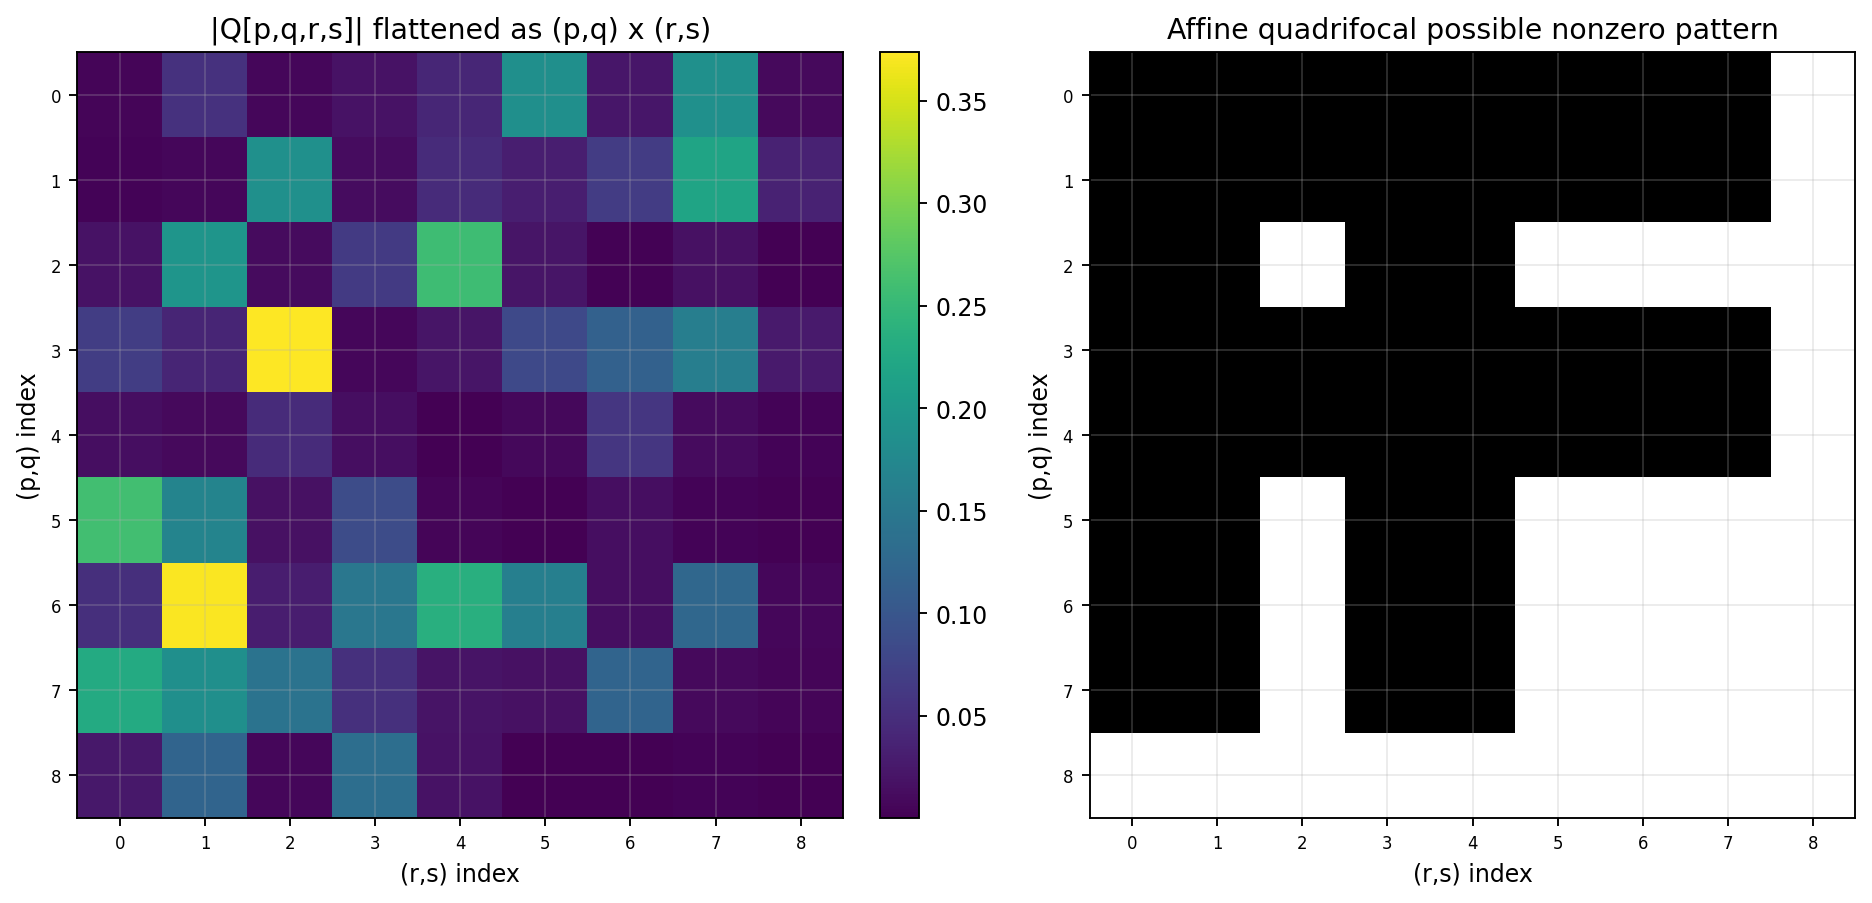

48

In [7]:
def make_affine_cameras() -> list[np.ndarray]:
    return [
        np.array([[1.0, 0.0, 0.0, 0.0], [0.0, 1.0, 0.0, 0.0], [0.0, 0.0, 0.0, 1.0]]),
        np.array([[1.0, 0.12, 0.05, 0.70], [-0.08, 0.95, 0.10, 0.25], [0.0, 0.0, 0.0, 1.0]]),
        np.array([[0.92, -0.15, 0.08, -0.42], [0.06, 1.08, -0.05, 0.38], [0.0, 0.0, 0.0, 1.0]]),
        np.array([[1.05, 0.05, -0.12, 0.32], [0.10, 0.98, 0.09, -0.55], [0.0, 0.0, 0.0, 1.0]]),
    ]

AQ = quadrifocal_from_rows(*make_affine_cameras())
Q_flat = np.abs(Q1234.reshape(9, 9))
affine_mask = (np.abs(AQ.reshape(9, 9)) > 1e-12).astype(int)
fig, axes = plt.subplots(1, 2, figsize=(12.0, 5.2), constrained_layout=True)
im0 = axes[0].imshow(Q_flat, cmap="viridis")
axes[0].set_title("|Q[p,q,r,s]| flattened as (p,q) x (r,s)")
axes[0].set_xlabel("(r,s) index")
axes[0].set_ylabel("(p,q) index")
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)
axes[1].imshow(affine_mask, cmap="Greys", vmin=0, vmax=1)
axes[1].set_title("Affine quadrifocal possible nonzero pattern")
axes[1].set_xlabel("(r,s) index")
axes[1].set_ylabel("(p,q) index")
for ax in axes:
    ax.set_xticks(range(9))
    ax.set_yticks(range(9))
    ax.tick_params(labelsize=7)
nonzero_count = int(affine_mask.sum())
validation["affine_quadrifocal_nonzero_count"] = nonzero_count
validation["affine_quadrifocal_expected_nonzero_count"] = 48
slices_path = save_matplotlib(fig, TOPIC, "figures", "quadrifocal-tensor-slices-and-affine-zero-pattern.png", dpi=170)
plt.close(fig)
figure_paths.append(slices_path)
display_artifact(slices_path, width=940)
nonzero_count


## Proof Scaffold: Why the Point-Equation Singular Values Match

For a point `x`, the matrix `S[w,p] = sum_i x_i epsilon[i,p,w]` is skew-symmetric up to index order. The identity

`S.T @ S = ||x||^2 I - x x.T`

shows that `S` has one zero singular value and two equal nonzero singular values. The four-view point equation matrix is a Kronecker product of four such matrices, so its nonzero singular values are all equal and only `2^4 = 16` survive.


In [8]:
x0, x1s, x2s = sp.symbols("x0 x1 x2")
S_sym = sp.Matrix([[0, -x2s, x1s], [x2s, 0, -x0], [-x1s, x0, 0]])
x_sym = sp.Matrix([x0, x1s, x2s])
identity_residual = sp.simplify(S_sym.T * S_sym - ((x_sym.dot(x_sym)) * sp.eye(3) - x_sym * x_sym.T))
validation["symbolic_skew_identity_zero"] = bool(identity_residual == sp.zeros(3))
identity_residual


Matrix([
[0, 0, 0],
[0, 0, 0],
[0, 0, 0]])

## Independent Equations from Four-View Point Tracks

The full point equation for the quadrifocal tensor has 81 rows because each free index ranges over three values. But each view contributes a rank-2 skew matrix, so one point track contributes rank `2^4 = 16`. A second track is not fully independent of the first; through five tracks the independent-equation count follows `16n - n(n-1)/2`. For six tracks the formula reaches 81, but a noise-free camera-consistent system still has the true quadrifocal tensor in its homogeneous nullspace, so the matrix rank caps at 80 and the tensor is determined up to scale.

The plot compares the dependency count, the homogeneous solve rank cap, and the tempting but wrong count `16n`. It also shows the singular values from one point track, where the 16 nonzero values are equal up to floating-point tolerance.


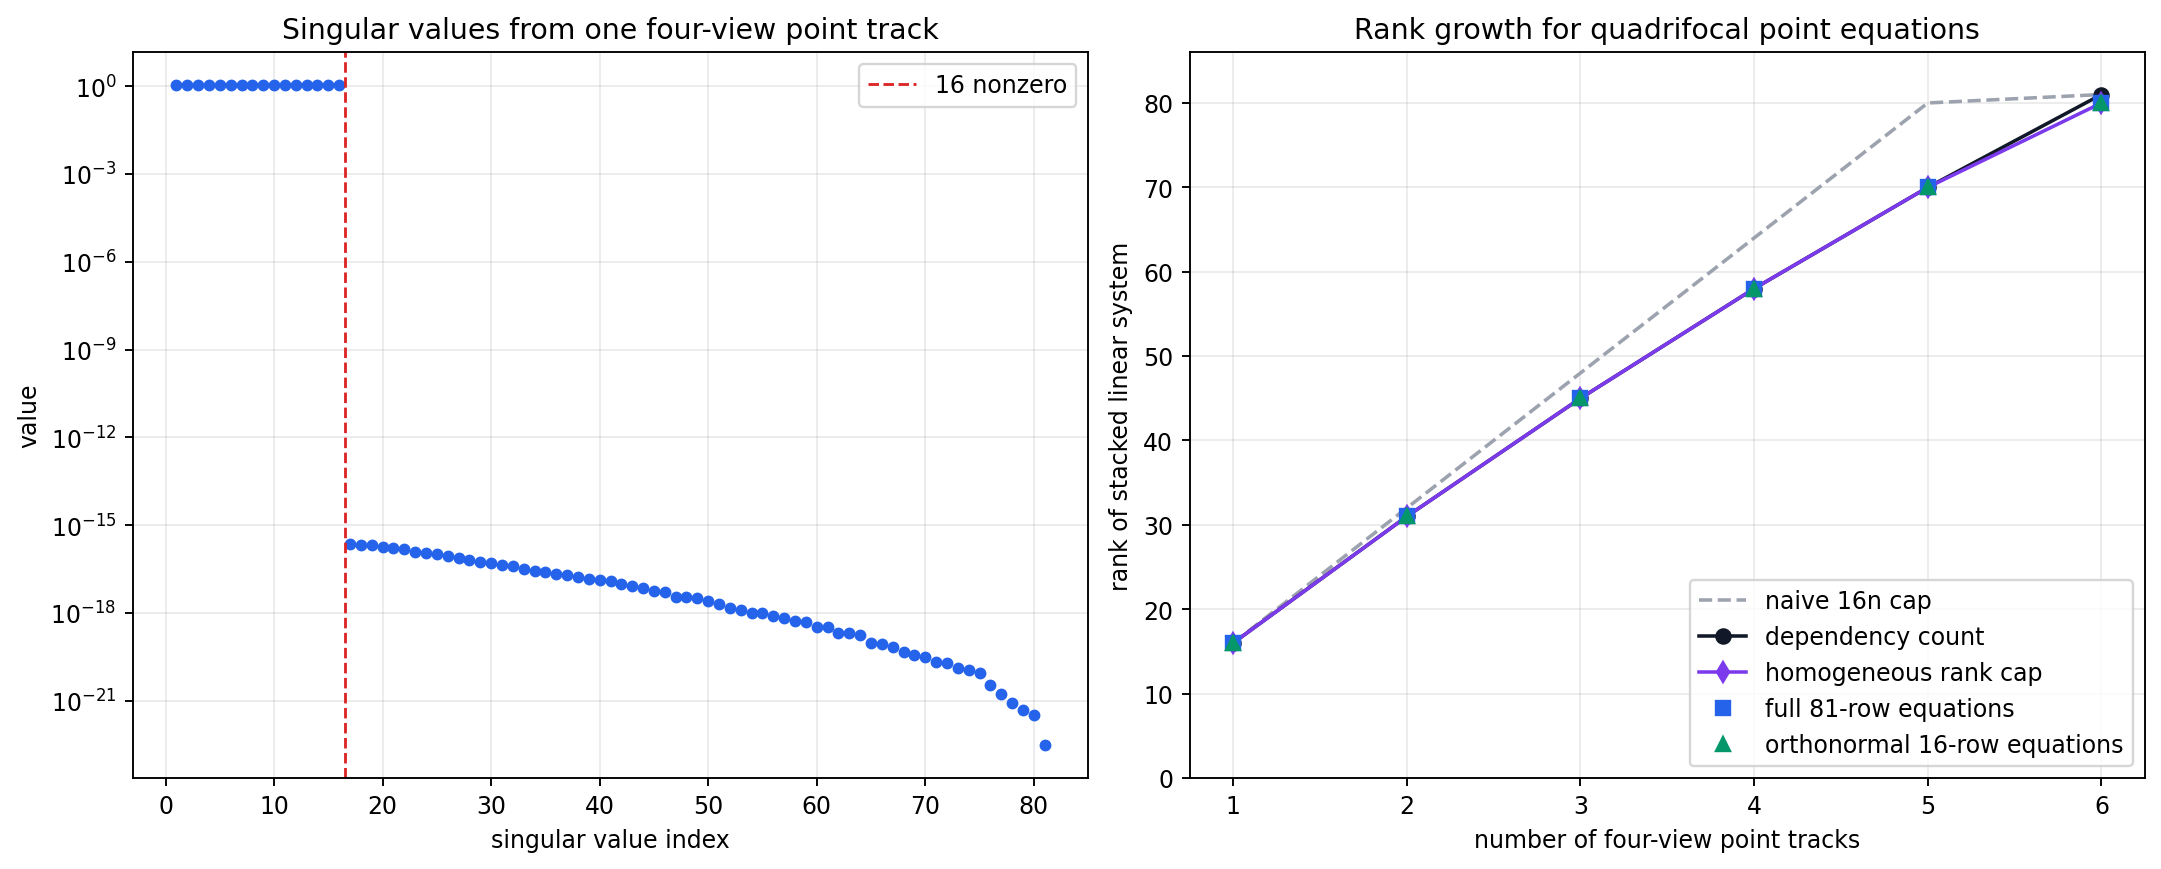

[quadrifocal-point-rank-profile.csv](Multiple-View-Geometry-in-Computer-Vision/artifacts/chapter-17/tables/quadrifocal-point-rank-profile.csv)

,tracks,full_rows,reduced_rows,full_rank,reduced_rank,dependency_count,homogeneous_rank_cap,naive_16n
0,1,81,16,16,16,16,16,16
1,2,162,32,31,31,31,31,32
2,3,243,48,45,45,45,45,48
3,4,324,64,58,58,58,58,64
4,5,405,80,70,70,70,70,80
5,6,486,96,80,80,81,80,81


In [9]:
def skew_equation_matrix(x: np.ndarray) -> np.ndarray:
    return np.einsum("i,ipw->wp", np.asarray(x, dtype=float), EPS)


def quadrifocal_point_equation_matrix(track: list[np.ndarray]) -> np.ndarray:
    S = [skew_equation_matrix(x) for x in track]
    return np.einsum("wp,xq,yr,zs->wxyzpqrs", *S).reshape(81, 81)


def orthonormal_lines_through_point(x: np.ndarray) -> np.ndarray:
    _, _, vt = np.linalg.svd(np.asarray(x, dtype=float).reshape(1, 3))
    return vt[1:].T


def reduced_quadrifocal_point_matrix(track: list[np.ndarray]) -> np.ndarray:
    L = [orthonormal_lines_through_point(x) for x in track]
    return np.einsum("pa,qb,rc,sd->abcdpqrs", *L).reshape(16, 81)


def numeric_rank(M: np.ndarray, reltol: float = 1e-9) -> int:
    s = np.linalg.svd(M, compute_uv=False)
    tol = reltol * max(M.shape) * (s[0] if s.size else 1.0)
    return int(np.sum(s > tol))

one_A = quadrifocal_point_equation_matrix(tracks[0])
one_s = np.linalg.svd(one_A, compute_uv=False)
nonzero_s = one_s[one_s > 1e-8 * one_s[0]]
rank_rows = []
for n in range(1, 7):
    stacked_full = np.vstack([quadrifocal_point_equation_matrix(track) for track in tracks[:n]])
    stacked_reduced = np.vstack([reduced_quadrifocal_point_matrix(track) for track in tracks[:n]])
    dependency_count = min(81, 16 * n - n * (n - 1) // 2)
    homogeneous_rank_cap = min(80, dependency_count)
    rank_rows.append({
        "tracks": n,
        "full_rows": int(stacked_full.shape[0]),
        "reduced_rows": int(stacked_reduced.shape[0]),
        "full_rank": numeric_rank(stacked_full),
        "reduced_rank": numeric_rank(stacked_reduced),
        "dependency_count": dependency_count,
        "homogeneous_rank_cap": homogeneous_rank_cap,
        "naive_16n": min(81, 16 * n),
    })
rank_df = pd.DataFrame(rank_rows)
fig, axes = plt.subplots(1, 2, figsize=(12.6, 5.0), constrained_layout=True)
axes[0].semilogy(np.arange(1, len(one_s) + 1), one_s, "o", markersize=4, color="#2563eb")
axes[0].axvline(16.5, color="#dc2626", linestyle="--", linewidth=1.2, label="16 nonzero")
axes[0].set_title("Singular values from one four-view point track")
axes[0].set_xlabel("singular value index")
axes[0].set_ylabel("value")
axes[0].legend()
axes[1].plot(rank_df["tracks"], rank_df["naive_16n"], "--", color="#9ca3af", label="naive 16n cap")
axes[1].plot(rank_df["tracks"], rank_df["dependency_count"], "o-", color="#111827", label="dependency count")
axes[1].plot(rank_df["tracks"], rank_df["homogeneous_rank_cap"], "d-", color="#7c3aed", label="homogeneous rank cap")
axes[1].plot(rank_df["tracks"], rank_df["full_rank"], "s", color="#2563eb", label="full 81-row equations")
axes[1].plot(rank_df["tracks"], rank_df["reduced_rank"], "^", color="#059669", label="orthonormal 16-row equations")
axes[1].set_title("Rank growth for quadrifocal point equations")
axes[1].set_xlabel("number of four-view point tracks")
axes[1].set_ylabel("rank of stacked linear system")
axes[1].set_xticks(rank_df["tracks"])
axes[1].set_ylim(0, 86)
axes[1].legend(loc="lower right")
rank_path = save_matplotlib(fig, TOPIC, "figures", "quadrifocal-point-rank-profile.png", dpi=170)
plt.close(fig)
figure_paths.append(rank_path)
rank_table_path = save_csv(rank_rows, TOPIC, "tables", "quadrifocal-point-rank-profile.csv")
data_paths.append(rank_table_path)
validation.update({
    "single_point_equation_rank": numeric_rank(one_A),
    "single_point_nonzero_singular_values": int(nonzero_s.size),
    "single_point_nonzero_singular_value_spread": float(nonzero_s.max() / nonzero_s.min()),
    "rank_profile": rank_rows,
})
display_artifact(rank_path, width=940)
display_artifact(rank_table_path)
rank_df


## Counting Arguments: Projective, Affine, and Plane-Plus-Parallax

Counting is not bookkeeping trivia in this chapter. It decides whether a linear tensor estimate is even plausible and whether a reduced parametrization already enforces geometric validity.

The dashboard below separates three regimes:

- projective cameras: `11m - 15` camera degrees of freedom;
- affine cameras: `8m - 12`, because the plane at infinity is fixed;
- known plane homographies: `3m - 4`, because only the last camera columns remain up to common scale.

These counts explain why four coplanar reference points can simplify the four-view problem so dramatically.


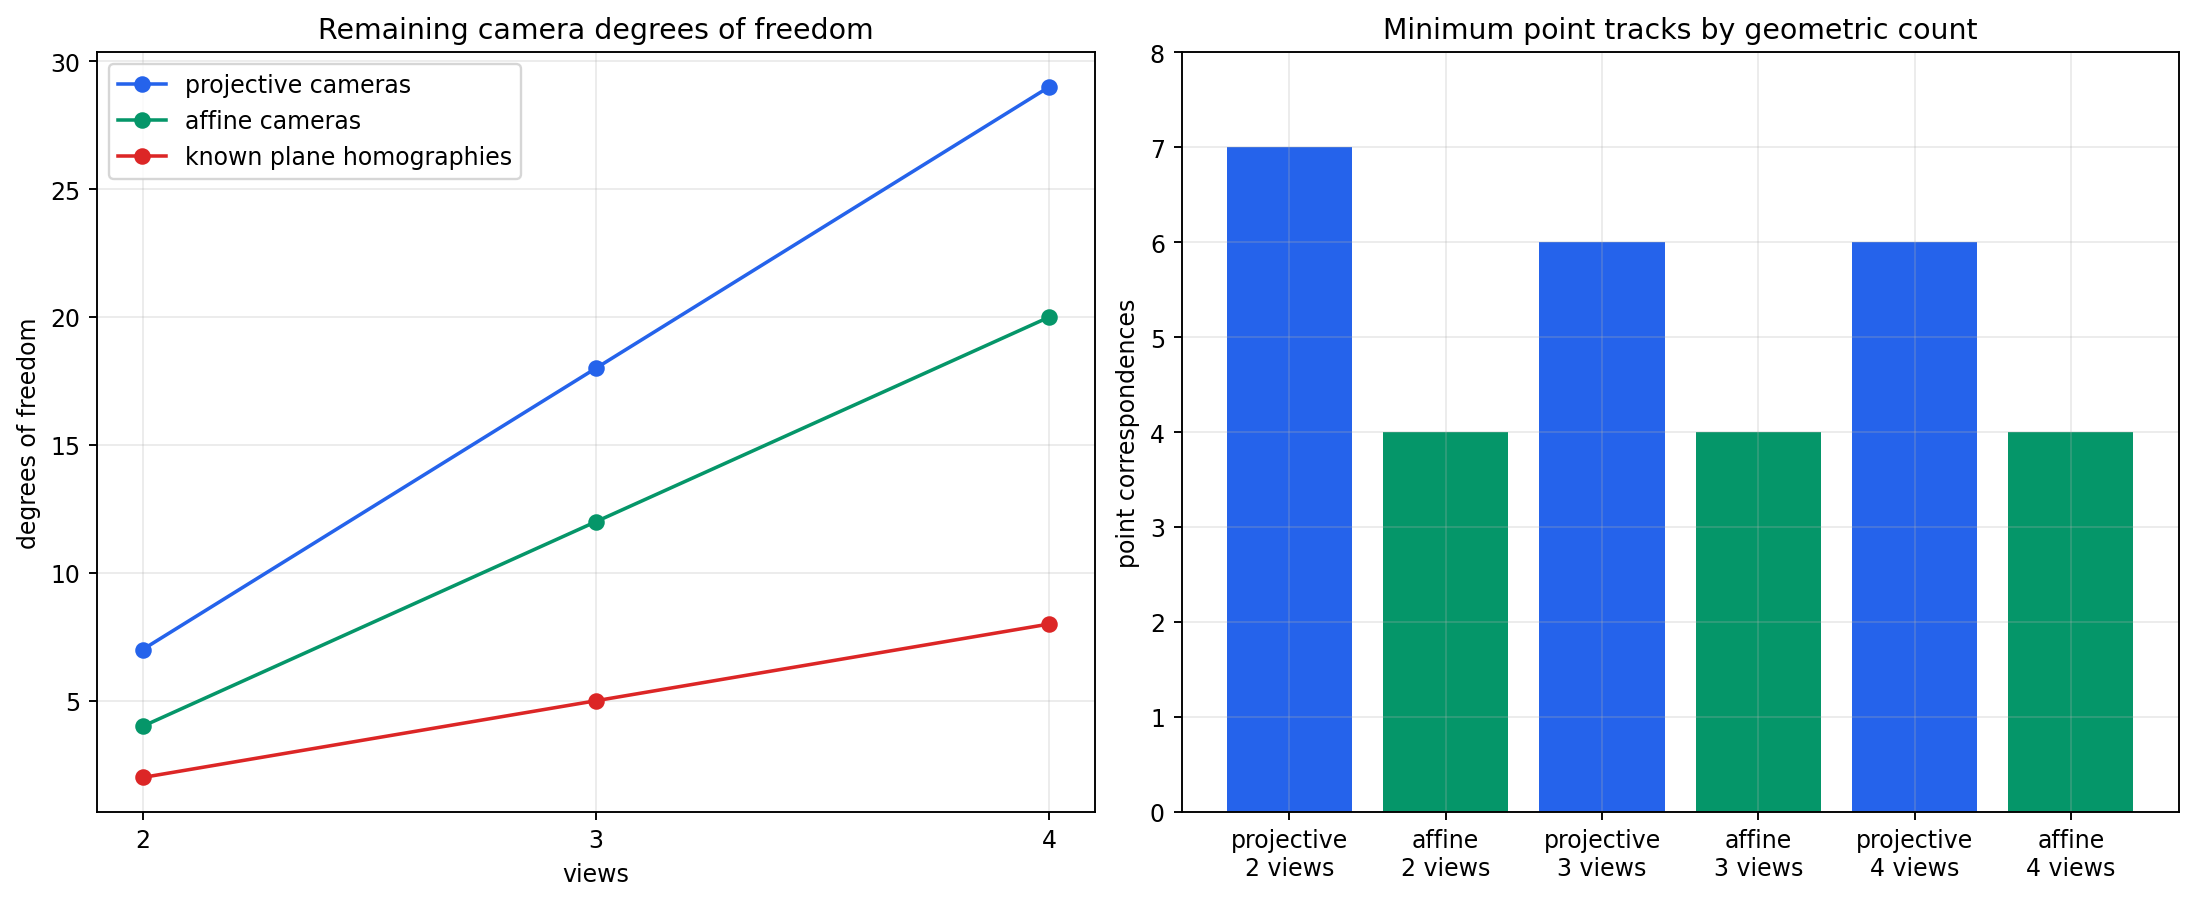

[correspondence-counts.csv](Multiple-View-Geometry-in-Computer-Vision/artifacts/chapter-17/tables/correspondence-counts.csv)

,regime,views,camera_dof,point_constraints_each,line_constraints_each,min_points_geometric,min_lines_geometric
0,projective cameras,2,7,1.0,NaN,7,NaN
1,affine cameras,2,4,1.0,NaN,4,NaN
2,known plane homographies,2,2,NaN,NaN,2,NaN
3,projective cameras,3,18,3.0,2.0,6,9.0
4,affine cameras,3,12,3.0,2.0,4,6.0
5,known plane homographies,3,5,NaN,1.0,2,5.0
6,projective cameras,4,29,5.0,4.0,6,8.0
7,affine cameras,4,20,5.0,4.0,4,5.0
8,known plane homographies,4,8,NaN,2.0,2,4.0


In [10]:
def ceil_div_float(x: float) -> int:
    return int(math.ceil(x - 1e-12))

count_rows = []
for m in [2, 3, 4]:
    projective_dof = 11 * m - 15
    affine_dof = 8 * m - 12
    plane_dof = 3 * m - 4
    point_constraints = 2 * m - 3
    line_constraints = 2 * m - 4
    count_rows.append({"regime": "projective cameras", "views": m, "camera_dof": projective_dof, "point_constraints_each": point_constraints, "line_constraints_each": line_constraints if line_constraints > 0 else None, "min_points_geometric": ceil_div_float(projective_dof / point_constraints), "min_lines_geometric": ceil_div_float(projective_dof / line_constraints) if line_constraints > 0 else None})
    count_rows.append({"regime": "affine cameras", "views": m, "camera_dof": affine_dof, "point_constraints_each": point_constraints, "line_constraints_each": line_constraints if line_constraints > 0 else None, "min_points_geometric": ceil_div_float(affine_dof / point_constraints), "min_lines_geometric": ceil_div_float(affine_dof / line_constraints) if line_constraints > 0 else None})
    count_rows.append({"regime": "known plane homographies", "views": m, "camera_dof": plane_dof, "point_constraints_each": None, "line_constraints_each": None if m == 2 else m - 2, "min_points_geometric": 2, "min_lines_geometric": None if m == 2 else ceil_div_float(plane_dof / (m - 2))})
count_df = pd.DataFrame(count_rows)
counts_path = save_csv(count_rows, TOPIC, "tables", "correspondence-counts.csv")
data_paths.append(counts_path)
fig, axes = plt.subplots(1, 2, figsize=(12.8, 5.2), constrained_layout=True)
for regime, color in [("projective cameras", "#2563eb"), ("affine cameras", "#059669"), ("known plane homographies", "#dc2626")]:
    sub = count_df[count_df["regime"] == regime]
    axes[0].plot(sub["views"], sub["camera_dof"], "o-", label=regime, color=color)
axes[0].set_title("Remaining camera degrees of freedom")
axes[0].set_xlabel("views")
axes[0].set_ylabel("degrees of freedom")
axes[0].set_xticks([2, 3, 4])
axes[0].legend()
plot_df = count_df[count_df["regime"].isin(["projective cameras", "affine cameras"])]
labels = [f"{r.regime.split()[0]}/n{int(r.views)} views" for r in plot_df.itertuples()]
axes[1].bar(np.arange(len(plot_df)), plot_df["min_points_geometric"], color=["#2563eb" if r == "projective cameras" else "#059669" for r in plot_df["regime"]])
axes[1].set_title("Minimum point tracks by geometric count")
axes[1].set_ylabel("point correspondences")
axes[1].set_xticks(np.arange(len(plot_df)), labels, rotation=0)
axes[1].set_ylim(0, 8)
count_path = save_matplotlib(fig, TOPIC, "figures", "correspondence-counting-dashboard.png", dpi=170)
plt.close(fig)
figure_paths.append(count_path)
validation["counting_selected_values"] = {
    "projective_4_view_dof": int(count_df[(count_df.regime == "projective cameras") & (count_df.views == 4)]["camera_dof"].iloc[0]),
    "affine_4_view_dof": int(count_df[(count_df.regime == "affine cameras") & (count_df.views == 4)]["camera_dof"].iloc[0]),
    "plane_homography_4_view_dof": int(count_df[(count_df.regime == "known plane homographies") & (count_df.views == 4)]["camera_dof"].iloc[0]),
}
display_artifact(count_path, width=940)
display_artifact(counts_path)
count_df


## Applied Lab: Choosing Equations Rather Than Hoarding Them

The source chapter recommends using all equations in some settings for numerical robustness, but it also explains how to choose orthonormal lines through each point so the point correspondence produces exactly the independent equations. The reduced construction below uses two orthonormal image lines through each measured point, producing `2^4 = 16` rows for a four-view point track.

The important inspection is not that the reduced system has fewer rows. It is that the reduced rows preserve the same rank profile while giving the nonzero singular values a controlled scale.


In [11]:
reduced_one = reduced_quadrifocal_point_matrix(tracks[0])
reduced_s = np.linalg.svd(reduced_one, compute_uv=False)
reduced_nonzero = reduced_s[reduced_s > 1e-10]
validation.update({
    "reduced_single_track_rows": int(reduced_one.shape[0]),
    "reduced_single_track_rank": numeric_rank(reduced_one),
    "reduced_single_track_singular_value_spread": float(reduced_nonzero.max() / reduced_nonzero.min()),
})
comparison = pd.DataFrame([
    {"system": "full skew product", "rows_per_track": 81, "rank_one_track": numeric_rank(one_A), "nonzero_singular_value_spread": validation["single_point_nonzero_singular_value_spread"]},
    {"system": "orthonormal line product", "rows_per_track": 16, "rank_one_track": numeric_rank(reduced_one), "nonzero_singular_value_spread": validation["reduced_single_track_singular_value_spread"]},
])
comparison


,system,rows_per_track,rank_one_track,nonzero_singular_value_spread
0,full skew product,81,16,1.0
1,orthonormal line product,16,16,1.0


## Final Sanity Checks

The checks below intentionally mix algebraic, geometric, numeric, and artifact assertions. A tensor notebook is not complete just because the arrays have the expected shape; the relations must vanish on consistent data, ranks must match the chapter's dependency claims, and every saved artifact must exist with nonzero size.


In [12]:
invariant_path = save_json({
    "source_span": "PDF pages 429-451; printed pages 411-433",
    "validation": validation,
    "artifacts": [relative_to_book(path, BOOK_ROOT) for path in [*figure_paths, *data_paths]],
}, TOPIC, "checks", "tensor-constraint-invariants.json")
data_paths.append(invariant_path)
display_artifact(invariant_path)

assert_artifacts(figure_paths, min_bytes=3000)
assert_artifacts(data_paths, min_bytes=40)
assert validation["tensor_shapes"] == {"F": [3, 3], "T": [3, 3, 3], "Q": [3, 3, 3, 3]}
assert validation["fundamental_rank"] == 2
assert validation["fundamental_det_abs"] < 1e-12
assert validation["fundamental_epipolar_abs"] < 1e-10
assert validation["trifocal_point_point_point_max_abs"] < 1e-10
assert validation["trifocal_point_line_line_abs"] < 1e-10
assert validation["quadrifocal_four_line_abs"] < 1e-10
assert validation["quadrifocal_three_corresponding_lines_norm"] < 1e-10
assert validation["backprojected_plane_det_abs"] < 1e-10
assert validation["max_line_incidence_abs"] < 1e-12
assert validation["max_plane_point_incidence_abs"] < 1e-10
assert validation["affine_quadrifocal_nonzero_count"] == 48
assert validation["symbolic_skew_identity_zero"] is True
assert validation["single_point_equation_rank"] == 16
assert validation["single_point_nonzero_singular_values"] == 16
assert abs(validation["single_point_nonzero_singular_value_spread"] - 1.0) < 1e-8
assert validation["reduced_single_track_rank"] == 16
assert abs(validation["reduced_single_track_singular_value_spread"] - 1.0) < 1e-8
for row in validation["rank_profile"]:
    assert row["full_rank"] == row["homogeneous_rank_cap"]
    assert row["reduced_rank"] == row["homogeneous_rank_cap"]
assert validation["counting_selected_values"] == {"projective_4_view_dof": 29, "affine_4_view_dof": 20, "plane_homography_4_view_dof": 8}
final_sanity = {
    "figures_checked": [relative_to_book(path, BOOK_ROOT) for path in figure_paths],
    "data_checked": [relative_to_book(path, BOOK_ROOT) for path in data_paths],
    "max_core_residual": max(validation["fundamental_epipolar_abs"], validation["trifocal_point_point_point_max_abs"], validation["trifocal_point_line_line_abs"], validation["quadrifocal_four_line_abs"], validation["quadrifocal_three_corresponding_lines_norm"], validation["backprojected_plane_det_abs"]),
    "rank_profile": validation["rank_profile"],
}
final_sanity


`artifacts/chapter-17/checks/tensor-constraint-invariants.json`

{'figures_checked': ['artifacts/chapter-17/figures/determinant-row-selection-ladder.png',
  'artifacts/chapter-17/interactive/backprojected-plane-intersection.html',
  'artifacts/chapter-17/figures/quadrifocal-tensor-slices-and-affine-zero-pattern.png',
  'artifacts/chapter-17/figures/quadrifocal-point-rank-profile.png',
  'artifacts/chapter-17/figures/correspondence-counting-dashboard.png'],
 'data_checked': ['artifacts/chapter-17/tables/quadrifocal-point-rank-profile.csv',
  'artifacts/chapter-17/tables/correspondence-counts.csv',
  'artifacts/chapter-17/checks/tensor-constraint-invariants.json'],
 'max_core_residual': 1.816970182976581e-16,
 'rank_profile': [{'tracks': 1,
   'full_rows': 81,
   'reduced_rows': 16,
   'full_rank': 16,
   'reduced_rank': 16,
   'dependency_count': 16,
   'homogeneous_rank_cap': 16,
   'naive_16n': 16},
  {'tracks': 2,
   'full_rows': 162,
   'reduced_rows': 32,
   'full_rank': 31,
   'reduced_rank': 31,
   'dependency_count': 31,
   'homogeneous_rank_

## Takeaways

- The fundamental matrix, trifocal tensor, and quadrifocal tensor are one determinant pattern seen at different view counts.
- Lines are often the cleanest way to state the geometry: image lines back-project to planes, and four planes meeting in a point is a determinant-zero condition.
- The quadrifocal tensor has 81 entries, but a valid four-view camera configuration has only 29 projective degrees of freedom; most raw tensor arrays are not geometrically valid.
- A four-view point track gives 16 independent equations. Five tracks do not give 80 independent constraints because pairwise dependencies remove rank; six camera-consistent tracks leave a one-dimensional nullspace, which is exactly what is needed to recover the tensor up to scale.
- Known plane homographies and affine cameras are not small variations of the general case. They change the remaining camera freedom and therefore change the correspondence counts.
